<a href="https://colab.research.google.com/github/Rahel000/computer-vision-and-deep-learning/blob/main/Transfer_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/Rahel000/computer-vision-and-deep-learning.git
%cd computer-vision-and-deep-learning
!ls

Cloning into 'computer-vision-and-deep-learning'...
remote: Enumerating objects: 109, done.
remote: Counting objects: 100% (109/109), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 109 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (109/109), 975.92 KiB | 3.12 MiB/s, done.
Resolving deltas: 100% (6/6), done.
/content/computer-vision-and-deep-learning
fork  metadata.csv  spoon


In [2]:
import torch, os

print("GPU aktif:", torch.cuda.is_available())
for kelas in ["spoon", "fork"]:
    print(kelas, "=", len(os.listdir(kelas)), "foto")

GPU aktif: True
spoon = 50 foto
fork = 50 foto


In [4]:
import os, random, shutil
random.seed(42)

kelas_list = ["spoon", "fork"]

for split in ["train", "val"]:
    for k in kelas_list:
        os.makedirs(f"data/{split}/{k}", exist_ok=True)

for k in kelas_list:
    files = sorted(f for f in os.listdir(k) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    random.shuffle(files)
    n_train = int(len(files) * 0.8)
    for i, f in enumerate(files):
        tujuan = "train" if i < n_train else "val"
        shutil.copy(f"{k}/{f}", f"data/{tujuan}/{k}/{f}")
    print(k, "-> train:", n_train, "| val:", len(files) - n_train)

spoon -> train: 40 | val: 10
fork -> train: 40 | val: 10


In [5]:
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder("data/train", tf)
val_ds = datasets.ImageFolder("data/val", tf)

train_dl = DataLoader(train_ds, batch_size=16, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=16)

print("Kelas:", train_ds.classes)
print("Jumlah train:", len(train_ds), "| val:", len(val_ds))

Kelas: ['fork', 'spoon']
Jumlah train: 80 | val: 20


In [6]:
import torch
import torch.nn as nn

device = "cuda"

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

for p in model.parameters():
    p.requires_grad = False          # kunci semua

model.fc = nn.Linear(model.fc.in_features, 2)   # kepala baru: spoon / fork
model = model.to(device)

print("Model siap")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 110MB/s]


Model siap


In [7]:
import time

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.fc.parameters(), lr=0.001)

hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
mulai = time.time()

for epoch in range(10):
    # --- belajar ---
    model.train()
    loss_sum, benar = 0, 0
    for x, y in train_dl:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * x.size(0)
        benar += (out.argmax(1) == y).sum().item()
    tr_loss, tr_acc = loss_sum / len(train_ds), benar / len(train_ds)

    # --- ujian ---
    model.eval()
    loss_sum, benar = 0, 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss_sum += criterion(out, y).item() * x.size(0)
            benar += (out.argmax(1) == y).sum().item()
    va_loss, va_acc = loss_sum / len(val_ds), benar / len(val_ds)

    hist["train_loss"].append(tr_loss); hist["val_loss"].append(va_loss)
    hist["train_acc"].append(tr_acc);   hist["val_acc"].append(va_acc)
    print(f"Epoch {epoch+1:2d} | train acc {tr_acc:.2%} | val acc {va_acc:.2%} | val loss {va_loss:.3f}")

print(f"Waktu training: {time.time() - mulai:.1f} detik")

Epoch  1 | train acc 50.00% | val acc 55.00% | val loss 0.687
Epoch  2 | train acc 82.50% | val acc 85.00% | val loss 0.609
Epoch  3 | train acc 90.00% | val acc 100.00% | val loss 0.549
Epoch  4 | train acc 92.50% | val acc 90.00% | val loss 0.525
Epoch  5 | train acc 91.25% | val acc 90.00% | val loss 0.515
Epoch  6 | train acc 93.75% | val acc 90.00% | val loss 0.488
Epoch  7 | train acc 98.75% | val acc 90.00% | val loss 0.482
Epoch  8 | train acc 98.75% | val acc 90.00% | val loss 0.464
Epoch  9 | train acc 98.75% | val acc 90.00% | val loss 0.449
Epoch 10 | train acc 95.00% | val acc 90.00% | val loss 0.436
Waktu training: 9.9 detik


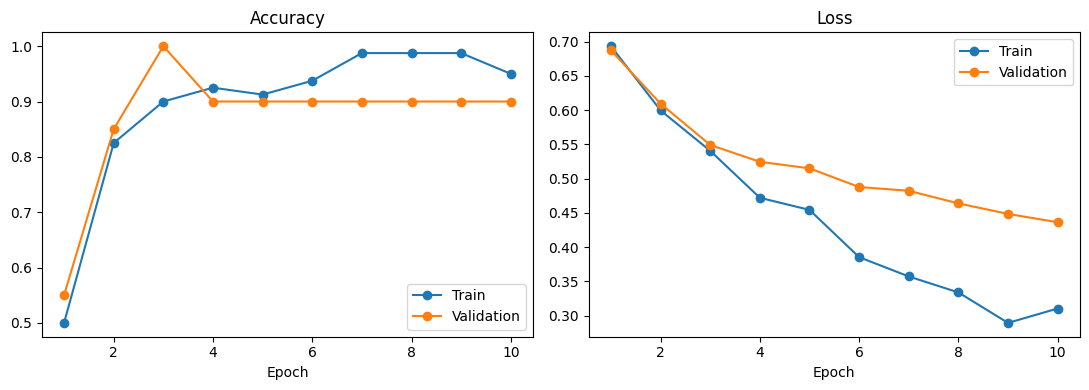

In [8]:
import matplotlib.pyplot as plt

ep = range(1, 11)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

ax[0].plot(ep, hist["train_acc"], marker="o", label="Train")
ax[0].plot(ep, hist["val_acc"], marker="o", label="Validation")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("Epoch"); ax[0].legend()

ax[1].plot(ep, hist["train_loss"], marker="o", label="Train")
ax[1].plot(ep, hist["val_loss"], marker="o", label="Validation")
ax[1].set_title("Loss"); ax[1].set_xlabel("Epoch"); ax[1].legend()

plt.tight_layout()
plt.savefig("grafik_feature_extraction.png", dpi=150)
plt.show()

Epoch  1 | train acc 58.75% | val acc 80.00% | val loss 0.636
Epoch  2 | train acc 92.50% | val acc 95.00% | val loss 0.495
Epoch  3 | train acc 96.25% | val acc 100.00% | val loss 0.300
Epoch  4 | train acc 100.00% | val acc 100.00% | val loss 0.158
Epoch  5 | train acc 100.00% | val acc 95.00% | val loss 0.111
Epoch  6 | train acc 98.75% | val acc 95.00% | val loss 0.087
Epoch  7 | train acc 100.00% | val acc 95.00% | val loss 0.118
Epoch  8 | train acc 100.00% | val acc 90.00% | val loss 0.137
Epoch  9 | train acc 100.00% | val acc 90.00% | val loss 0.169
Epoch 10 | train acc 100.00% | val acc 90.00% | val loss 0.136
Waktu training: 8.3 detik


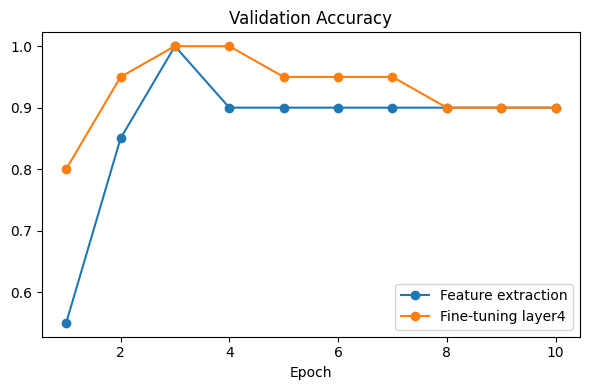

In [9]:
def latih(model, optimizer, epochs=10):
    h = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    mulai = time.time()
    for epoch in range(epochs):
        model.train()
        ls, bn = 0, 0
        for x, y in train_dl:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            ls += loss.item() * x.size(0)
            bn += (out.argmax(1) == y).sum().item()
        tr_loss, tr_acc = ls / len(train_ds), bn / len(train_ds)

        model.eval()
        ls, bn = 0, 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(device), y.to(device)
                out = model(x)
                ls += criterion(out, y).item() * x.size(0)
                bn += (out.argmax(1) == y).sum().item()
        va_loss, va_acc = ls / len(val_ds), bn / len(val_ds)

        h["train_loss"].append(tr_loss); h["val_loss"].append(va_loss)
        h["train_acc"].append(tr_acc);   h["val_acc"].append(va_acc)
        print(f"Epoch {epoch+1:2d} | train acc {tr_acc:.2%} | val acc {va_acc:.2%} | val loss {va_loss:.3f}")
    print(f"Waktu training: {time.time() - mulai:.1f} detik")
    return h

# model baru: layer4 + classifier boleh belajar
model2 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
for p in model2.parameters():
    p.requires_grad = False
for p in model2.layer4.parameters():
    p.requires_grad = True
model2.fc = nn.Linear(model2.fc.in_features, 2)
model2 = model2.to(device)

opt2 = torch.optim.Adam([
    {"params": model2.layer4.parameters(), "lr": 1e-4},
    {"params": model2.fc.parameters(), "lr": 1e-3},
])

hist2 = latih(model2, opt2)

# grafik perbandingan
plt.figure(figsize=(6, 4))
plt.plot(range(1, 11), hist["val_acc"], marker="o", label="Feature extraction")
plt.plot(range(1, 11), hist2["val_acc"], marker="o", label="Fine-tuning layer4")
plt.title("Validation Accuracy"); plt.xlabel("Epoch"); plt.legend()
plt.tight_layout()
plt.savefig("grafik_perbandingan.png", dpi=150)
plt.show()